# Import Functions

In [2]:
!nvidia-smi

Fri Feb 14 12:40:24 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.120                Driver Version: 550.120        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               Off |   00000000:01:00.0 Off |                  Off |
| 30%   29C    P8             18W /  300W |      11MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import sys 
!{sys.executable} -m pip install torchvision==0.17.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 128.7 MB/s eta 0:00:00
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.16.0+cu121
    Uninstalling torchvision-0.16.0+cu121:
      Successfully uninstalled torchvision-0.16.0+cu121


In [2]:
import sys 
!{sys.executable} -m pip install auto4dstem==0.2.7

In [3]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="5"
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
import numpy as np 
import matplotlib.pyplot as plt 
from torch.autograd import Function
from collections import OrderedDict
import torch.nn as nn
import math
import pickle
import torch.autograd as autograd
import matplotlib.gridspec as gridspec
import os
import h5py
from tqdm import tqdm
from scipy import ndimage
import matplotlib.pyplot as plt
import skimage
from skimage.feature import peak_local_max
from skimage import data, img_as_float,feature
from skimage import io
import cv2

In [4]:
import torchvision
from torchvision import models, transforms, datasets

In [5]:
import matplotlib.pylab as pylab

params = {'axes.titlesize':20,
          'xtick.direction': 'in' ,
          'ytick.direction' : 'in',
          'xtick.top' : True,
          'ytick.right' : True,
          'ytick.labelsize':16,
          'xtick.labelsize':16
         }

pylab.rcParams.update(params)

In [6]:
torch.__version__

'2.2.0+cu121'

In [7]:
torchvision.__version__

'0.17.0+cu121'

In [8]:
#import atomai as aoi
#import kornia as K
import cv2
import scipy
import argparse
import skimage
from skimage.util import random_noise
from skimage import feature
import glob
from scipy import ndimage
import scipy as sp
import random

In [9]:
import warnings
warnings.filterwarnings('ignore') 

In [10]:
from functools import partial
import numpy as np
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import random_split

In [11]:
%load_ext autoreload
%autoreload 2
from auto4dstem.nn.Train_Function import TrainClass
from auto4dstem.Viz.util import mask_class
from auto4dstem.Viz.viz import set_format_Auto4D, visualize_simulate_result, visual_performance_plot,normalized_strain_matrices
# #from auto4dstem.Data.DataProcess import *
# from auto4dstem.nn.CC_ST_AE import *
# from auto4dstem.nn.Loss_Function import *
# from auto4dstem.nn.Train_Function import *
# from auto4dstem.Viz.util import *
# from auto4dstem.Viz.viz import *
from m3util.util.IO import make_folder
import warnings
warnings.filterwarnings('ignore') 

In [12]:
torch.cuda.device_count()

1

# Build two type of mask for two training process

In [13]:
def load_data(data_dir, w_bg=0.60):
    
    '''
    
        data_dir: path of the dataset
        label_index: path of the pretrained rotation 
    
    '''
    
    f = h5py.File(data_dir,'r')
    op4d = f['output4D']
    op4d = op4d[:,:,28:228,28:228]
    op4d = np.transpose(op4d, (1, 0, 3, 2))
    op4d = op4d.reshape(-1,200,200)
    f.close()
    
    if w_bg == 0:
        
        noisy_data = op4d*1e5/4
    
    else:
    
        noisy_data = np.zeros([65536,200,200])
        im=np.zeros([200,200])
        counts_per_probe = 1e5
        for i in tqdm(range(65536),leave=True,total=65536):
            test_img = np.copy(op4d[i])
            qx = np.fft.fftfreq( im.shape[0], d = 1)
            qy = np.fft.fftfreq( im.shape[1], d = 1)
            qya, qxa = np.meshgrid(qy, qx)
            qxa = np.fft.fftshift(qxa)
            qya = np.fft.fftshift(qya) 
            qra2 = qxa**2 + qya**2
            im_bg = 1./( 1 + qra2 / 1e-2**2 )
            im_bg = im_bg / np.sum(im_bg) 
            int_comb = test_img * (1 - w_bg) + im_bg * w_bg 
            int_noisy = np.random.poisson(int_comb * counts_per_probe) / counts_per_probe
            int_noisy = int_noisy*1e5/4
            noisy_data[i] = int_noisy
        
    del op4d
    
    noisy_data = noisy_data.reshape(-1,1,200,200)
#     angle = np.mod(np.arctan2(
#         pre_rot[:,1].reshape(256,256),
#         pre_rot[:,0].reshape(256,256)),np.pi/3).reshape(-1)
    
    
#     # combine the data and label for test
#     whole_data_with_rotation = []
#     for i in tqdm(range(noisy_data.shape[0]),leave=True, total=noisy_data.shape[0]):
#         whole_data_with_rotation.append([noisy_data[i], angle[i]])
        
    return noisy_data

## Set the mask function

## Set a 200x200 image

# Loading Data

In [14]:
# Set data direction
data_dir = os.path.abspath("Extremely_Noisy_4DSTEM_Strain_Mapping_Using_CC_ST_AE_Simulated/polycrystal_output4D.mat")
folder_name = ''

In [15]:
data_dir

'/home/shuyu/4DSTEM/Simulated_4dstem/Extremely_Noisy_4DSTEM_Strain_Mapping_Using_CC_ST_AE_Simulated/polycrystal_output4D.mat'

# Integrate Label 

In [16]:
folder_name = folder_name = 'Extremely_Noisy_4DSTEM_Strain_Mapping_Using_CC_ST_AE_Simulated'
label_rotation_path = folder_name +'/Label_rotation.npy'
label_xx_path = folder_name +'/Label_strain_xx.npy'
label_yy_path = folder_name +'/Label_strain_yy.npy'
label_xy_path = folder_name +'/Label_shear_xy.npy'

In [17]:
label_xx_path

'Extremely_Noisy_4DSTEM_Strain_Mapping_Using_CC_ST_AE_Simulated/Label_strain_xx.npy'

In [18]:
label_xx = np.load(label_xx_path).reshape(-1)
label_yy = np.load(label_yy_path).reshape(-1)
label_xy = np.load(label_xy_path).reshape(-1)
label_rot = np.load(label_rotation_path).reshape(-1)

In [19]:
label_cat = np.stack([label_xx,label_yy,label_xy,label_rot])

In [20]:
label_cat = np.transpose(label_cat,(1,0))

In [21]:
label_cat.shape

(65536, 4)

In [22]:
label_cat[0]

array([-0.04201891, -0.02528346, -0.02672141,  1.79829708])

In [23]:
x_train = load_data(data_dir,w_bg=0.25)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 65536/65536 [01:36<00:00, 681.08it/s]


In [24]:
x_train.shape

(65536, 1, 200, 200)

In [25]:
def train_with_label(x,y):
    x_with_y = []
    for i in tqdm(range(x.shape[0]),leave=True, total=x.shape[0]):
        x_with_y.append([x[i], y[i]])
    return x_with_y

In [26]:
train_set = train_with_label(x_train,label_cat)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 65536/65536 [00:00<00:00, 328542.73it/s]


In [27]:
train_set[0][1].shape

(4,)

In [28]:
del(x_train)

In [29]:
device = torch.device('cuda')

# ResNet 50

In [30]:
resnet50 = models.resnet50(pretrained=True)
num_ftrs = resnet50.fc.in_features

In [31]:
num_ftrs

2048

In [32]:
resnet50.fc = nn.Linear(num_ftrs, 4)

In [33]:
resnet50.conv1 = nn.Conv2d(
            1, 64, kernel_size=(7,7), stride=(2,2), padding=(3,3), bias=False
        )

In [34]:
resnet50

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Loss Function

In [35]:
def loss_function_strain(model,
                      train_iterator,
                      optimizer,
                      device,
                     ):

    # set the train mode
    model.train()

    # loss of the epoch
    train_loss = 0
    
    for x,y in tqdm(train_iterator, leave=True, total=len(train_iterator)):
     

        x = x.to(device, dtype=torch.float)
        y = y.to(device, dtype=torch.float)
        optimizer.zero_grad()
        

        y_pred = model(x)
        
        loss = F.mse_loss(y,y_pred)
    
        train_loss += loss.item()
        loss.backward()
        # update the weights
        optimizer.step()

    return train_loss

# Train Function

In [37]:
folder_path = 'Resnet50_25Per_4dstem' 

In [40]:
def train(data_,
         model,
         optimizer,
         epochs=5000,   
         learning_rate = 1e-4,
         max_rate = 1e-3,
         batch_size = 64,
         epoch_ = None,
         file_path = None,
         folder_path=folder_path,
         step_size_up=50,
         best_train_loss= None,
         set_scheduler = True,
        ):
        
            make_folder(folder_path)            
            device = "cpu"
            if torch.cuda.is_available():
                device = "cuda"
            seed = 42
            random.seed(seed)
            np.random.seed(seed)
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed(seed)
            # put model on device
            model.to(device)
            print('.........b step.........')
            patience = 0


            if set_scheduler:

                lr_scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=learning_rate, max_lr=max_rate,
                                                      step_size_up=step_size_up,cycle_momentum=False)
            else: 

                lr_scheduler = None


            print('..........successfully generate model')

            train_iterator = DataLoader(data_, batch_size=batch_size, shuffle=True, num_workers=0)


            N_EPOCHS = epochs

            if best_train_loss == None:
                best_train_loss = float('inf')


            if epoch_==None:
                start_epoch = 0
            else:
                start_epoch = epoch_+1
            print('...........successfully generate train interator')

            for epoch in range(start_epoch,epochs):

                optimizer.param_groups[0]['lr'] = learning_rate   

                train = loss_function_strain(model,train_iterator,
                                      optimizer,device)

                input_length = len(train_iterator)


                train_loss = train

                train_loss /= input_length

        #        VAE_L /= len(train_iterator)
                print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}')
        #        print(f'......... VAE Loss: {VAE_L:.4f}')
                print('.............................')

                checkpoint = {
                    "net":model.state_dict(),
                    'optimizer': optimizer.state_dict(),
                    "epoch": epoch,
                    'trainloss': train_loss,
                }
                if epoch >=0:
                    lr_ = optimizer.param_groups[0]['lr']
    #                    l1_form = format(coef_1,'.4f')
                    file_path = folder_path+f'/0215_25Per_epoch:{epoch:04d}_lr:{lr_:.6f}_trainloss:{train_loss:.6f}_.pkl'

                    if best_train_loss >= train_loss:
                        best_train_loss = train_loss
                        torch.save(checkpoint, file_path)
                    else:
                        patience+=1
                        
                        if patience >=100:
                            break


                                

                if lr_scheduler!= None:
                    lr_scheduler.step()
                    
                if epoch==epochs-1:
                    del model

In [41]:
optimizer = optim.Adam(resnet50.parameters(),lr=1e-4)

In [42]:
train(train_set,resnet50,optimizer)

.........b step.........
..........successfully generate model
...........successfully generate train interator


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [34:20<00:00,  2.01s/it]


Epoch 0, Train Loss: 0.0098
.............................


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [35:04<00:00,  2.06s/it]


Epoch 1, Train Loss: 0.0010
.............................


...

Epoch 146, Train Loss: 0.0000
.............................


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [43:43<00:00,  2.56s/it]


Epoch 147, Train Loss: 0.0000
.............................


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [43:39<00:00,  2.56s/it]

Epoch 148, Train Loss: 0.0000
.............................


In [35]:
def Generate_scale_shear_loss(exx_Shuyu,eyy_Shuyu,exy_Shuyu,label_xx,label_yy,label_xy):
    dif_shuyu_xx = exx_Shuyu - label_xx
    dif_shuyu_yy = eyy_Shuyu - label_yy
    dif_shuyu_xy = exy_Shuyu - label_xy
    mae_shuyu_xx = np.mean(abs(dif_shuyu_xx)) 
    mae_shuyu_yy = np.mean(abs(dif_shuyu_yy)) 
    mae_shuyu_xy = np.mean(abs(dif_shuyu_xy)) 
    
    combine_loss = mae_shuyu_xx + mae_shuyu_yy + mae_shuyu_xy
    
    return combine_loss

def basis2probe(rotation_,
                scale_shear_):

    M = []
    
    for i in tqdm(range(rotation_.shape[0]),leave=True,total=rotation_.shape[0]):
        
        # switch cosine and sine into radius
        theta = np.arctan2(rotation_[i][1], rotation_[i][0]) 
        
        # generate scale transformation matrix and rotation transformation matrix with parameters from corresponding input index
        xx = scale_shear_[i][0]
        yy = scale_shear_[i][3]
        xy = scale_shear_[i][1]
        yx = scale_shear_[i][2]

        # generate rotation matrix with cosine and sine value
        r = np.array([
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta),  np.cos(theta)]
            ])
        
        # generate scale and shear with input value 
        t = np.array([
            [xx,xy],
            [yx,yy]
            ])
        
        # matrix multiplication 
        m = np.linalg.inv(t) @ np.linalg.inv(r)

        M.append(m)

    M  = np.array(M)
    return M

def inverse_base(name_of_file, input_mask_list, coef=2, radius=7):
    """generate updated mask list that center the spots

    Args:
        name_of_file (string): file directory
        input_mask_list (list of tensor): mask list used for updating
        coef (float): threshold for center the spots. Defaults to 2.
        radius (int): radius of updated mask. Defaults to 7.

    Returns:
        list of tensor, tensor: mask list and mask
    """
    # load h5 file 
    load_file = h5py.File(name_of_file + ".h5", "r")
    # load base image
    load_base = load_file["base"][0].squeeze()
    # reshape base 
    base_ = torch.tensor(load_base, dtype=torch.float).reshape(
        1, 1, load_base.shape[-1], load_base.shape[-2]
    )
    # update mask list region using center_mask_list_function
    center_mask_list, rotate_center = center_mask_list_function(
        base_, input_mask_list, coef, radius=radius
    )

    return center_mask_list, rotate_center

def center_mask_list_function(image, mask_list, coef, radius=7):
    # create mask list
    center_mask_list = []
    # create image with zero value
    mean_ = np.zeros([image.shape[-2], image.shape[-1]])

    input_size = mask_list[0].shape[-1]
    up_size = image.shape[-1]
    # upgrid image if necessary
    if input_size != up_size:
        mask_list = upsample_mask(mask_list, input_size, up_size)

    for j, mask in enumerate(mask_list):
        mask_ = mask.reshape(1, 1, mask.shape[-2], mask.shape[-1])

        new_image = image * mask_
    # compute coordinate with center of mass 
        center_x, center_y = center_of_mass(new_image.squeeze(), mask_.squeeze(), coef)

        center_x = int(np.round(np.array(center_x)))
        center_y = int(np.round(np.array(center_y)))
        print(center_x, center_y)
    # create small mask region using center coordinate
        small_mask = mask_function(
            mean_, radius=radius, center_coordinates=(center_y, center_x)
        )
    # switch type into tensor
        small_mask = torch.tensor(small_mask, dtype=torch.bool)

        center_mask_list.append(small_mask)
    # change mask size if necessary
    if input_size != up_size:
        center_mask_list = upsample_mask(center_mask_list, up_size, input_size)
    # create whole mask region in one image
    rotate_mask_up = torch.clone(center_mask_list[0])

    for i in range(1, len(center_mask_list)):
        rotate_mask_up += center_mask_list[i]

    return center_mask_list, rotate_mask_up

In [37]:
label_xx = np.load('Label_strain_xx.npy')
label_yy = np.load('Label_strain_yy.npy')
label_xy = np.load('Label_shear_xy.npy')

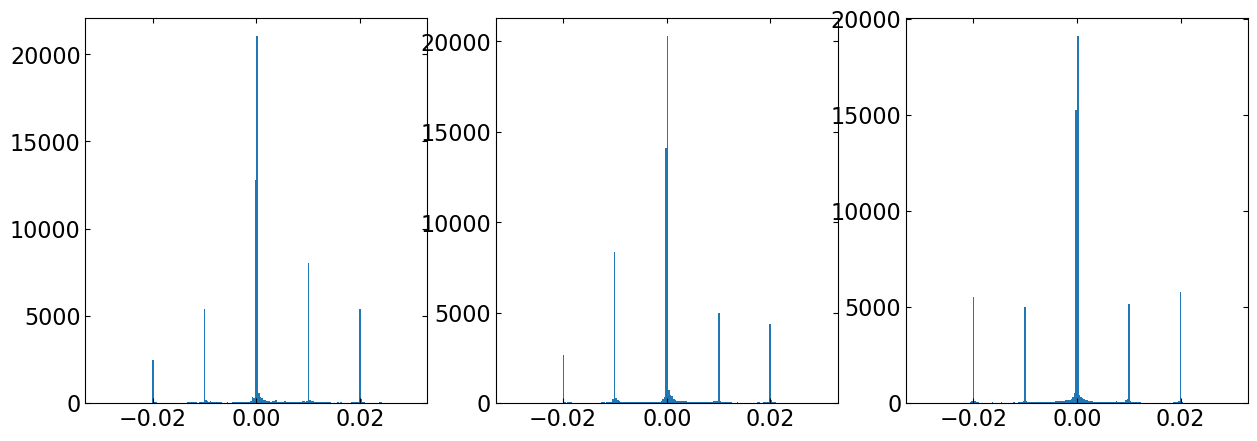

In [38]:
fig,ax = plt.subplots(1,3,figsize=(15,5))
ax[0].hist(label_xx.reshape(-1),200,range=[-0.03,0.03]);
ax[1].hist(label_yy.reshape(-1),200,range=[-0.03,0.03]);
ax[2].hist(label_xy.reshape(-1),200,range=[-0.03,0.03]);

# Second training process
### set training parameters

In [50]:
train_without_rotation(data_dir)

.........a step.........successfully create dataset
.........b step.........
........successfully load parameters


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 65536/65536 [02:01<00:00, 539.95it/s]


..........successfully generate model
...........successfully generate train interator


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [18:37<00:00,  1.09s/it]


Epoch 0, Train Loss: 0.0280
.............................


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [18:30<00:00,  1.08s/it]


Epoch 3, Train Loss: 0.0260
.............................


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [18:30<00:00,  1.08s/it]


Epoch 4, Train Loss: 0.0260
.............................


 63%|████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                                             | 645/1024 [11:39<06:52,  1.09s/it]IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [51]:
noisy_data = load_data(data_dir,w_bg=0.25)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 65536/65536 [02:01<00:00, 538.98it/s]


In [95]:
batch_size = 256
train_iterator = DataLoader(noisy_data, batch_size=batch_size, shuffle=False, num_workers=0)

In [96]:
encoder, join,decoder,optimizer = make_model_2(device,learning_rate = 3e-5,fixed_mask = center_mask_list,interpolate = True)

In [97]:
check_path = '1007_25BKG_DATA_Pytorch_2nd/1007_lr:0.000104_scale_cof:100.000_shear_cof:10.000_MAE:0.0049_epoch:0038_trainloss:0.025750_mask:0.00408_scal:0.00000_shr:0.00000.pkl'

In [98]:
check_point = torch.load(check_path)

In [99]:
encoder.load_state_dict(check_point['encoder'])
join.load_state_dict(check_point['join'])

<All keys matched successfully>

In [100]:
# # save weight
# checkpoint = {
#     "encoder":encoder.state_dict(),
#     "decoder":decoder.state_dict(),
#     "join":join.state_dict(),
#     'optimizer': optimizer.state_dict(),
# }

# torch.save(checkpoint, 'test_pytorch_weight_1004.pkl')

In [101]:
learned_rotation_1 = np.zeros([65536,2])
learned_rotation_2 = np.zeros([65536,2])
learned_scale_shear_ = np.zeros([65536,4])
encoder_out = np.zeros([65536,4])
decoder_out = np.zeros([65536,4])
for i, x in enumerate(tqdm(train_iterator,leave=True,total=len(train_iterator))):
    with torch.no_grad():
#         value,rot = x
#         rot = Variable(rot.cuda()).float()
#         test_value = Variable(value.cuda())
        x = x.float()
#        predicted_x,rot_1,out= encoder(x.to(device, dtype=torch.float))
        
        out_2nd_affine,out_1st_affine,scale_shear,rot_1,rot_2,x_inp,vec,vec_2 = join(x.to(device, dtype=torch.float))
        
        learned_rotation_1[i*batch_size:(i+1)*batch_size] = rot_1[:,:,0].cpu().detach().numpy()
        learned_rotation_2[i*batch_size:(i+1)*batch_size] = rot_2[:,:,0].cpu().detach().numpy()

        learned_scale_shear_[i*batch_size:(i+1)*batch_size] = scale_shear[:,:,0:2].cpu().detach().numpy().reshape(-1,4)
        encoder_out[i*batch_size:(i+1)*batch_size] = vec.cpu().detach().numpy()
        decoder_out[i*batch_size:(i+1)*batch_size] = vec_2.cpu().detach().numpy()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [06:58<00:00,  1.64s/it]


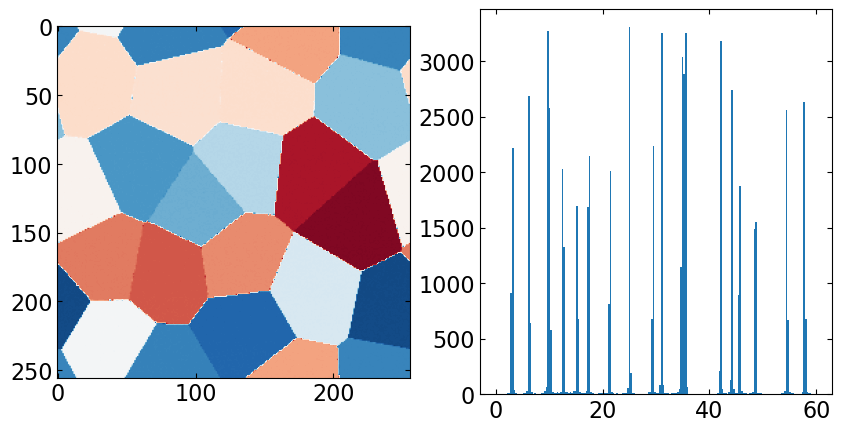

In [102]:
shift_angle = -23
gouba = np.mod(shift_angle + 1*np.rad2deg(np.arctan2(
                        learned_rotation_1[:,1].reshape(-1),
                        learned_rotation_1[:,0].reshape(-1))
                                         ),60)

fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(gouba.reshape(256,256),cmap = 'RdBu_r',clim=[0,60])
ax[1].hist(gouba.reshape(-1),200,range=[0,60]);

In [103]:
test_iterator = torch.utils.data.DataLoader(noisy_data, batch_size = 120,shuffle = True)
sample = next(iter(test_iterator))

In [104]:
out_2nd_affine,out_1st_affine,scale_shear,rot_1,rot_2,x_inp,_,_= join(sample.to(device, dtype=torch.float))

In [105]:
predicted_base = torch.load('25Per_base_cpu_1st.pt')

In [106]:
out_2nd_affine,out_1st_affine,scale_shear,rot_1,rot_2,x_inp= join(sample.to(device, dtype=torch.float))

ValueError: too many values to unpack (expected 6)

In [ ]:
def visual_weighted_mse(x,y,para=3,reverse=0):
    # make input all torch img
    img_size = torch.zeros(x.shape)
    if reverse%2==0:
        
        diff = y-x
    else:
    
        diff = x-y
    
    index_pos = torch.where(diff>0)
    index_neg = torch.where(diff<0)
    
    img_size[index_pos] = diff[index_pos]**2
    img_size[index_neg] = para*diff[index_neg]**2

    return img_size

In [ ]:
fig,ax = plt.subplots(6,4,figsize=(20,30))
for i in range(6):
    j = np.random.randint(0,16)
    #i = 247
    if i==0:
        ax[i][0].title.set_text('input image')
        ax[i][1].title.set_text('affine transform')
        ax[i][2].title.set_text('basis')
        ax[i][3].title.set_text('reverse affine to input')
    ax[i][0].imshow(sample[j].squeeze(),clim=[0,1])
    
    
    predicted_mask = out_1st_affine[j].squeeze().detach().cpu()
#    predicted_mask[~mask_up_1]=0
    ax[i][1].imshow(predicted_mask,clim=[0,1])
    predicted_base = predicted_base.squeeze().detach().cpu()
    ax[i][2].imshow(predicted_base,clim=[0,1])
    
    diff = visual_weighted_mse(predicted_base,predicted_mask,para=3)
    ax[i][3].imshow(diff,clim=[0,0.3])
    
    
    # generate rotation
#    print('strain:',theta_1[j])
    print('rotation:',rot_1[j])

In [ ]:
shift_angle = -9
gouba = np.mod(shift_angle + 1*np.rad2deg(np.arctan2(
                        learned_rotation_2[:,1].reshape(-1),
                        learned_rotation_2[:,0].reshape(-1))
                                         ),60)

fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(gouba.reshape(256,256),cmap = 'RdBu_r',clim=[0,60])
ax[1].hist(gouba.reshape(-1),200,range=[0,60]);

In [ ]:
predicted_base_1 = torch.load('25Per_base_cpu.pt')
predicted_base_up = F.interpolate(predicted_base_1.unsqueeze(0).unsqueeze(1), size=(800,800),mode = 'bicubic').squeeze()
rotate_mask_up = upsample_mask([rotate_center],200,800)

strain: tensor([[1.0085, 0.0013, 0.0000],
        [0.0013, 1.0084, 0.0000]], device='cuda:0', grad_fn=<SelectBackward0>)
rotation: tensor([[ 0.9500, -0.3122,  0.0000],
        [ 0.3122,  0.9500,  0.0000]], device='cuda:0',
       grad_fn=<SelectBackward0>)
strain: tensor([[1.0068, 0.0020, 0.0000],
        [0.0020, 1.0196, 0.0000]], device='cuda:0', grad_fn=<SelectBackward0>)
rotation: tensor([[ 0.9047, -0.4261,  0.0000],
        [ 0.4261,  0.9047,  0.0000]], device='cuda:0',
       grad_fn=<SelectBackward0>)
strain: tensor([[ 1.0075e+00, -5.4944e-04,  0.0000e+00],
        [-5.4944e-04,  1.0004e+00,  0.0000e+00]], device='cuda:0',
       grad_fn=<SelectBackward0>)
rotation: tensor([[ 0.6313, -0.7756,  0.0000],
        [ 0.7756,  0.6313,  0.0000]], device='cuda:0',
       grad_fn=<SelectBackward0>)
strain: tensor([[1.0068, 0.0020, 0.0000],
        [0.0020, 1.0196, 0.0000]], device='cuda:0', grad_fn=<SelectBackward0>)
rotation: tensor([[ 0.9047, -0.4261,  0.0000],
        [ 0.4261,  0.904

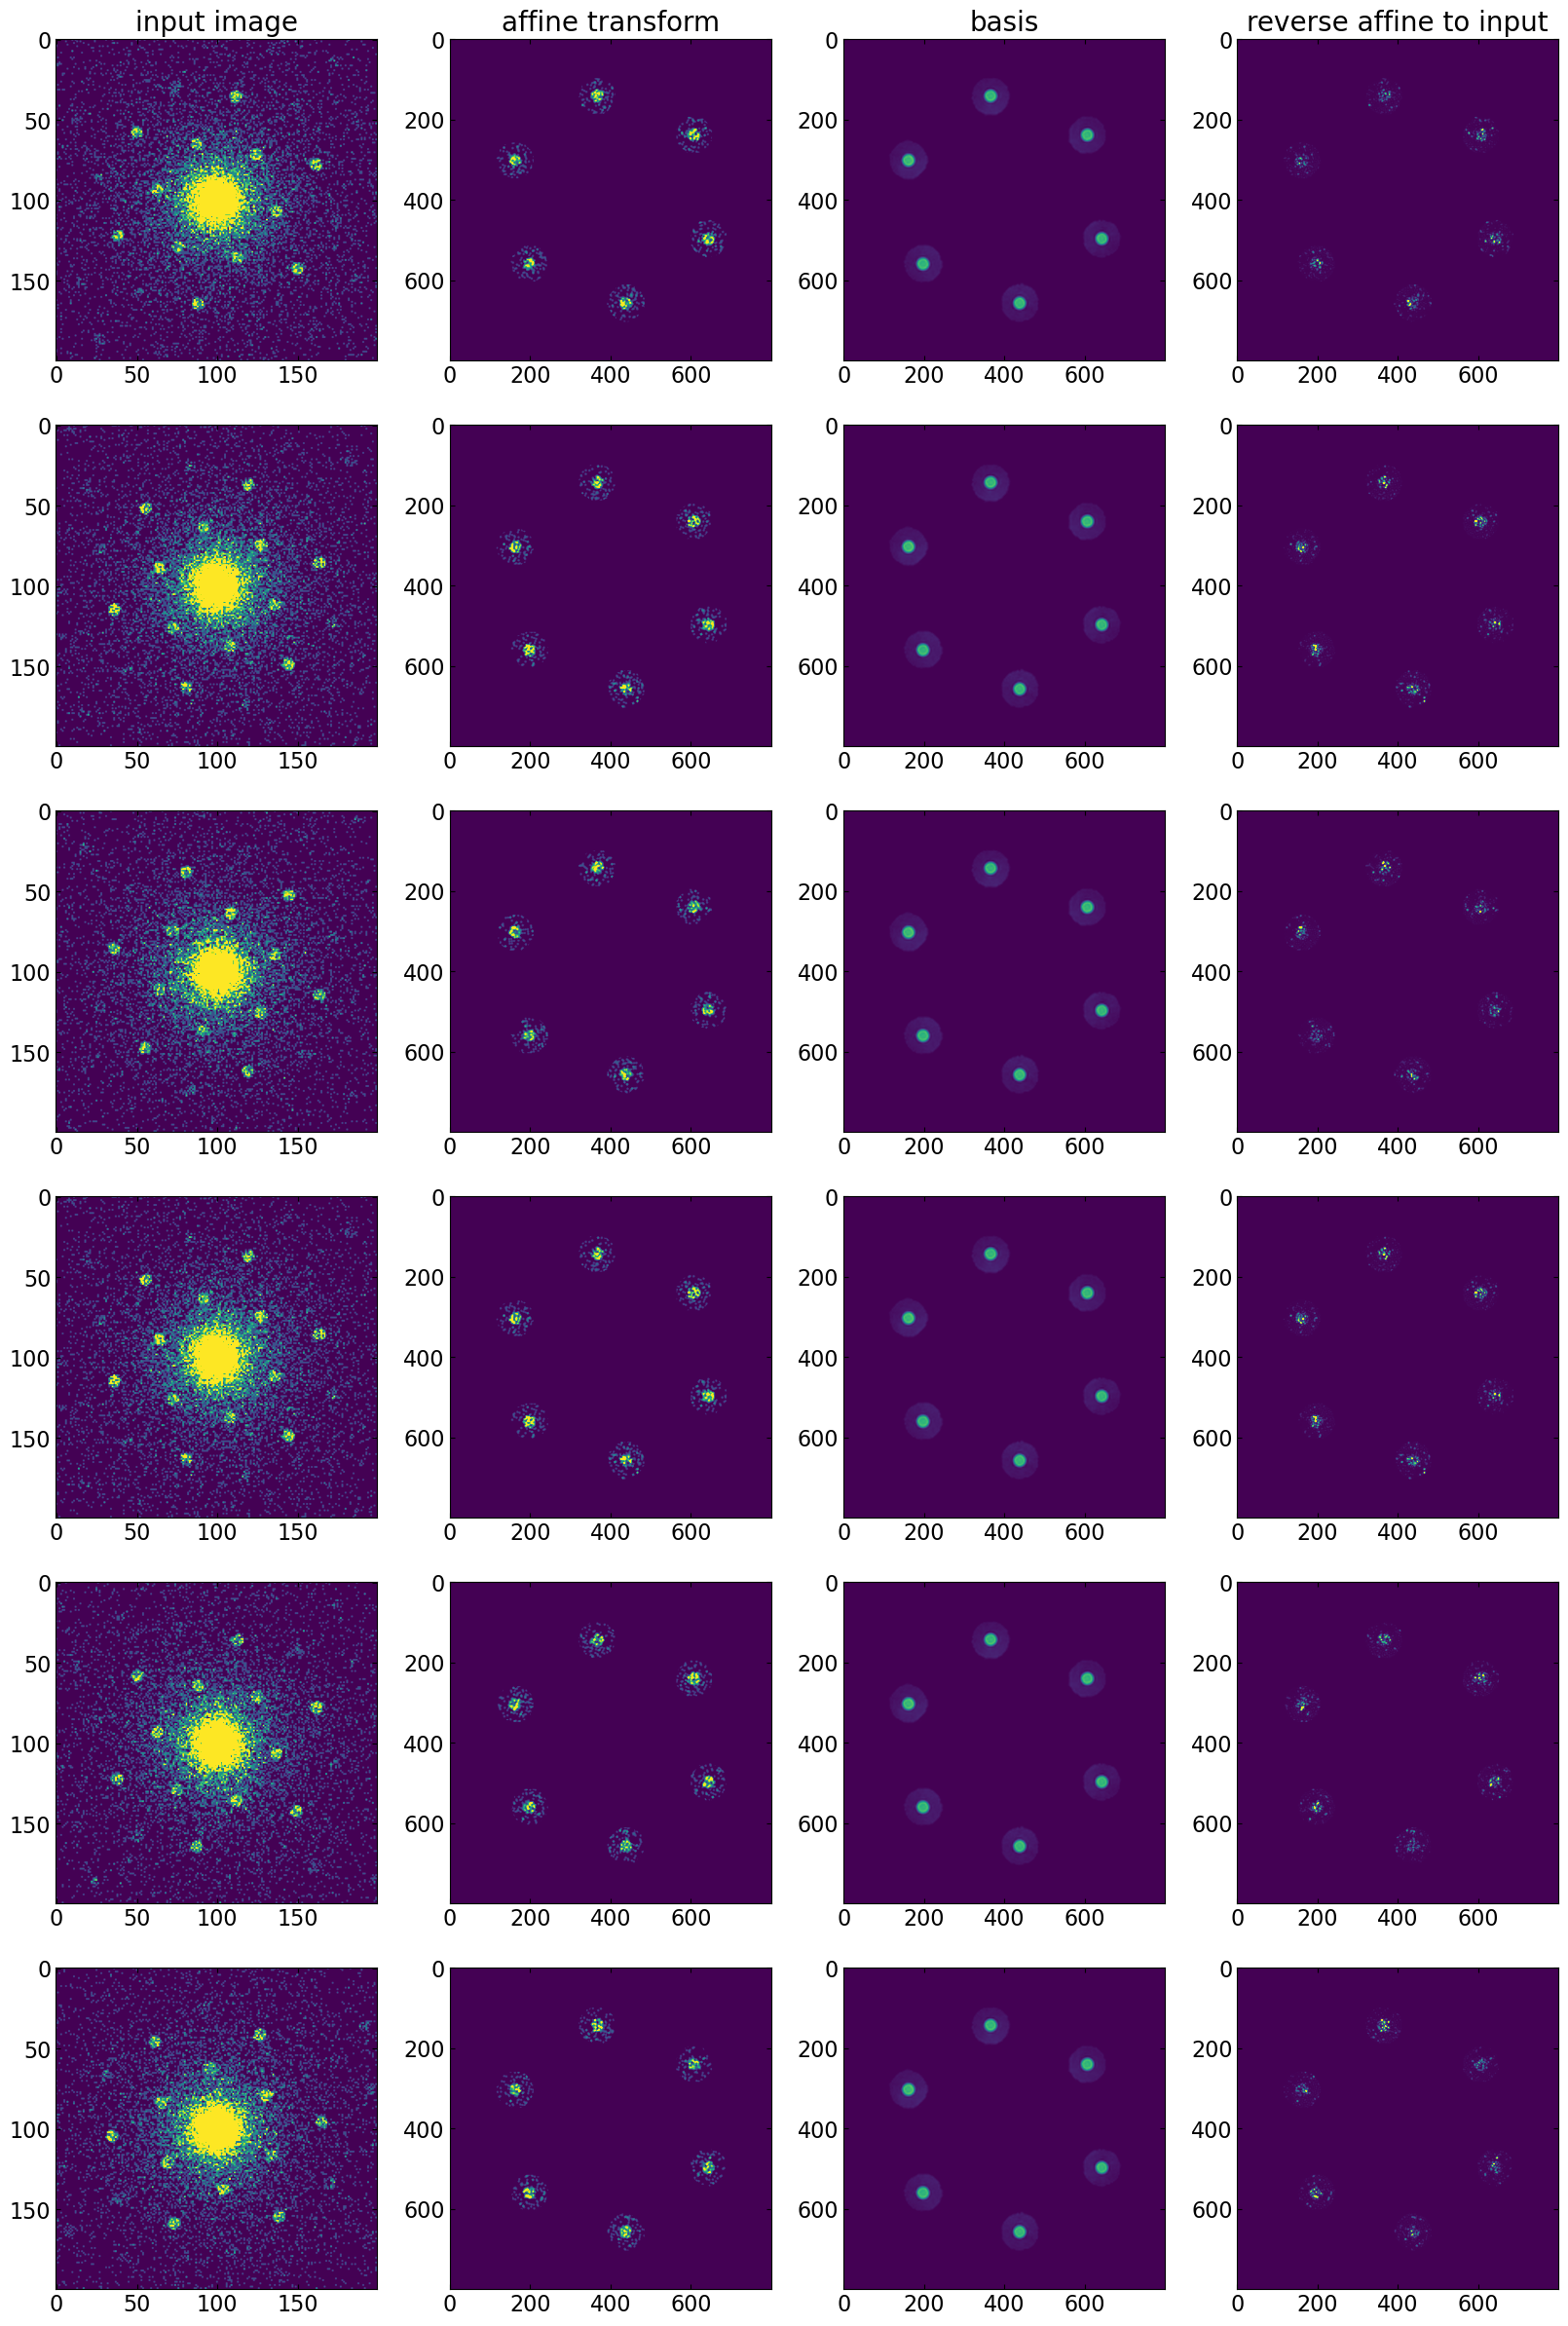

In [107]:
fig,ax = plt.subplots(6,4,figsize=(20,30))
for i in range(6):
    j = np.random.randint(0,16)
    #i = 247
    if i==0:
        ax[i][0].title.set_text('input image')
        ax[i][1].title.set_text('affine transform')
        ax[i][2].title.set_text('basis')
        ax[i][3].title.set_text('reverse affine to input')
    ax[i][0].imshow(sample[j].squeeze(),clim=[0,1])
    
    
    predicted_mask = out_2nd_affine[j].squeeze().detach().cpu()
    predicted_mask[~rotate_mask_up[0]]=0
    ax[i][1].imshow(predicted_mask,clim=[0,1])
    predicted_base_up = predicted_base_up.squeeze().detach().cpu()
    ax[i][2].imshow(predicted_base_up,clim=[0,1])
    
    #diff = visual_weighted_mse(predicted_base,predicted_mask,para=3)
    diff = (predicted_base_up-predicted_mask)**2
    ax[i][3].imshow(diff,clim=[0,0.5])
    
    
    # generate rotation
    print('strain:',scale_shear[j])
    print('rotation:',rot_2[j])

In [108]:
from cmcrameri import cm

In [109]:
bkg_intensity = 0.25
folder_name = 'Extremely_Noisy_4DSTEM_Strain_Mapping_Using_CC_ST_AE_Simulated'
bkg_str = format(int(bkg_intensity*100),'02d')
rotation_path = f'{folder_name}/{bkg_str}Per_2_train_process_rotation.npy'
strain_path = f'{folder_name}/{bkg_str}Per_2_train_process_scale_shear.npy'
file_py4DSTEM = f'{folder_name}/analysis_bg{bkg_str}per_1e5counts__strain.h5'
rotation_25 = learned_rotation_2
scale_shear_25 = learned_scale_shear_

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 65536/65536 [00:01<00:00, 39730.20it/s]


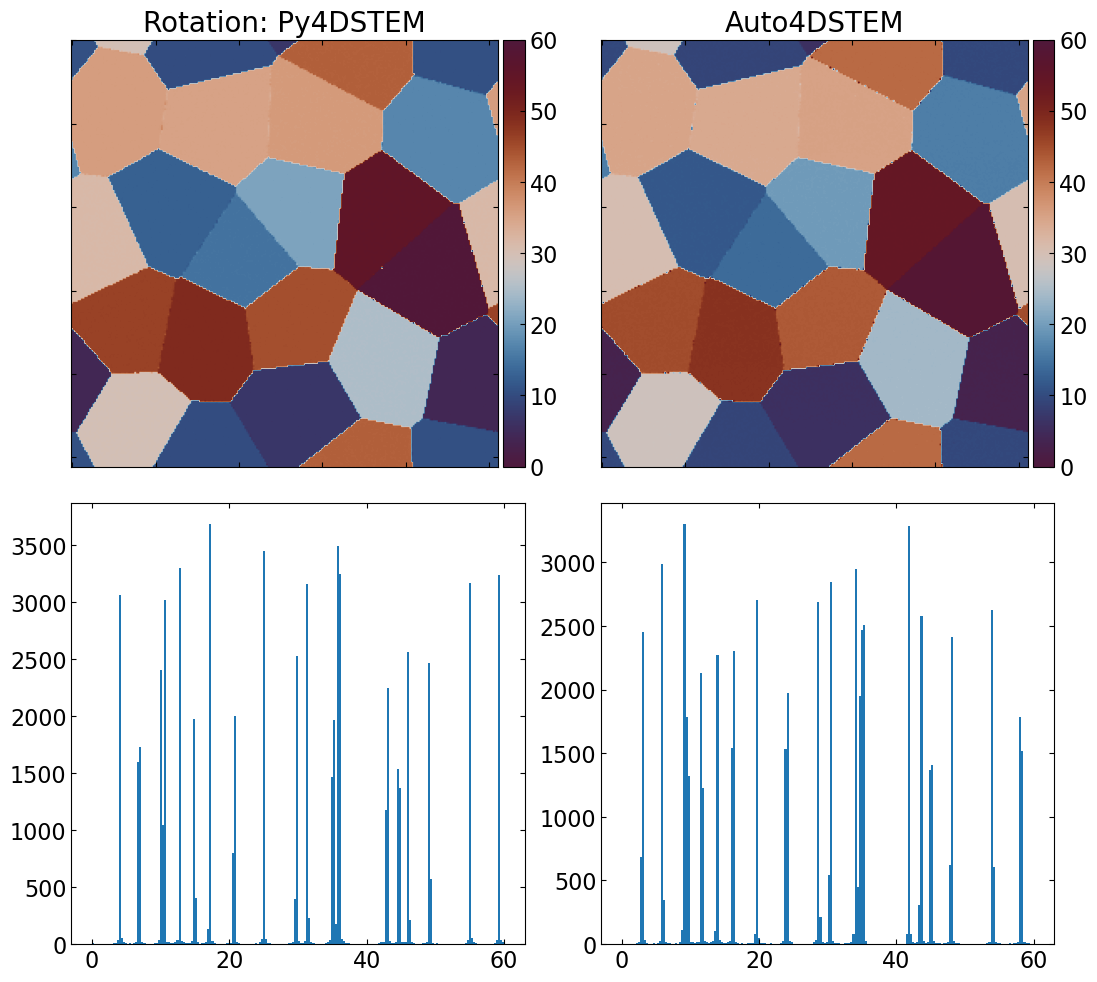

In [110]:
visual = visualize_simulate_result(rotation =  rotation_25,
                                scale_shear = scale_shear_25,
                                file_py4DSTEM = file_py4DSTEM,
                                label_rotation_path = folder_name +'/Label_rotation.npy',
                                label_xx_path = folder_name +'/Label_strain_xx.npy',
                                label_yy_path = folder_name +'/Label_strain_yy.npy',
                                label_xy_path = folder_name +'/Label_shear_xy.npy',
                                cmap_rotation = cm.vikO,
                                cmap_strain= cm.vik,
                                cmap_mae=cm.vik,
                                noise_intensity = bkg_intensity,
                                angle_shift = -9,
                                strain_diff_range = [-0.03,0.03],
                                strain_rotation_range = [-40,30],
                                mae_diff_range = [-0.006,0.006],
                                mae_rotation_range = [-0.5,0.5],
                                folder_name = 'HAWQ_RESULT'
                               )

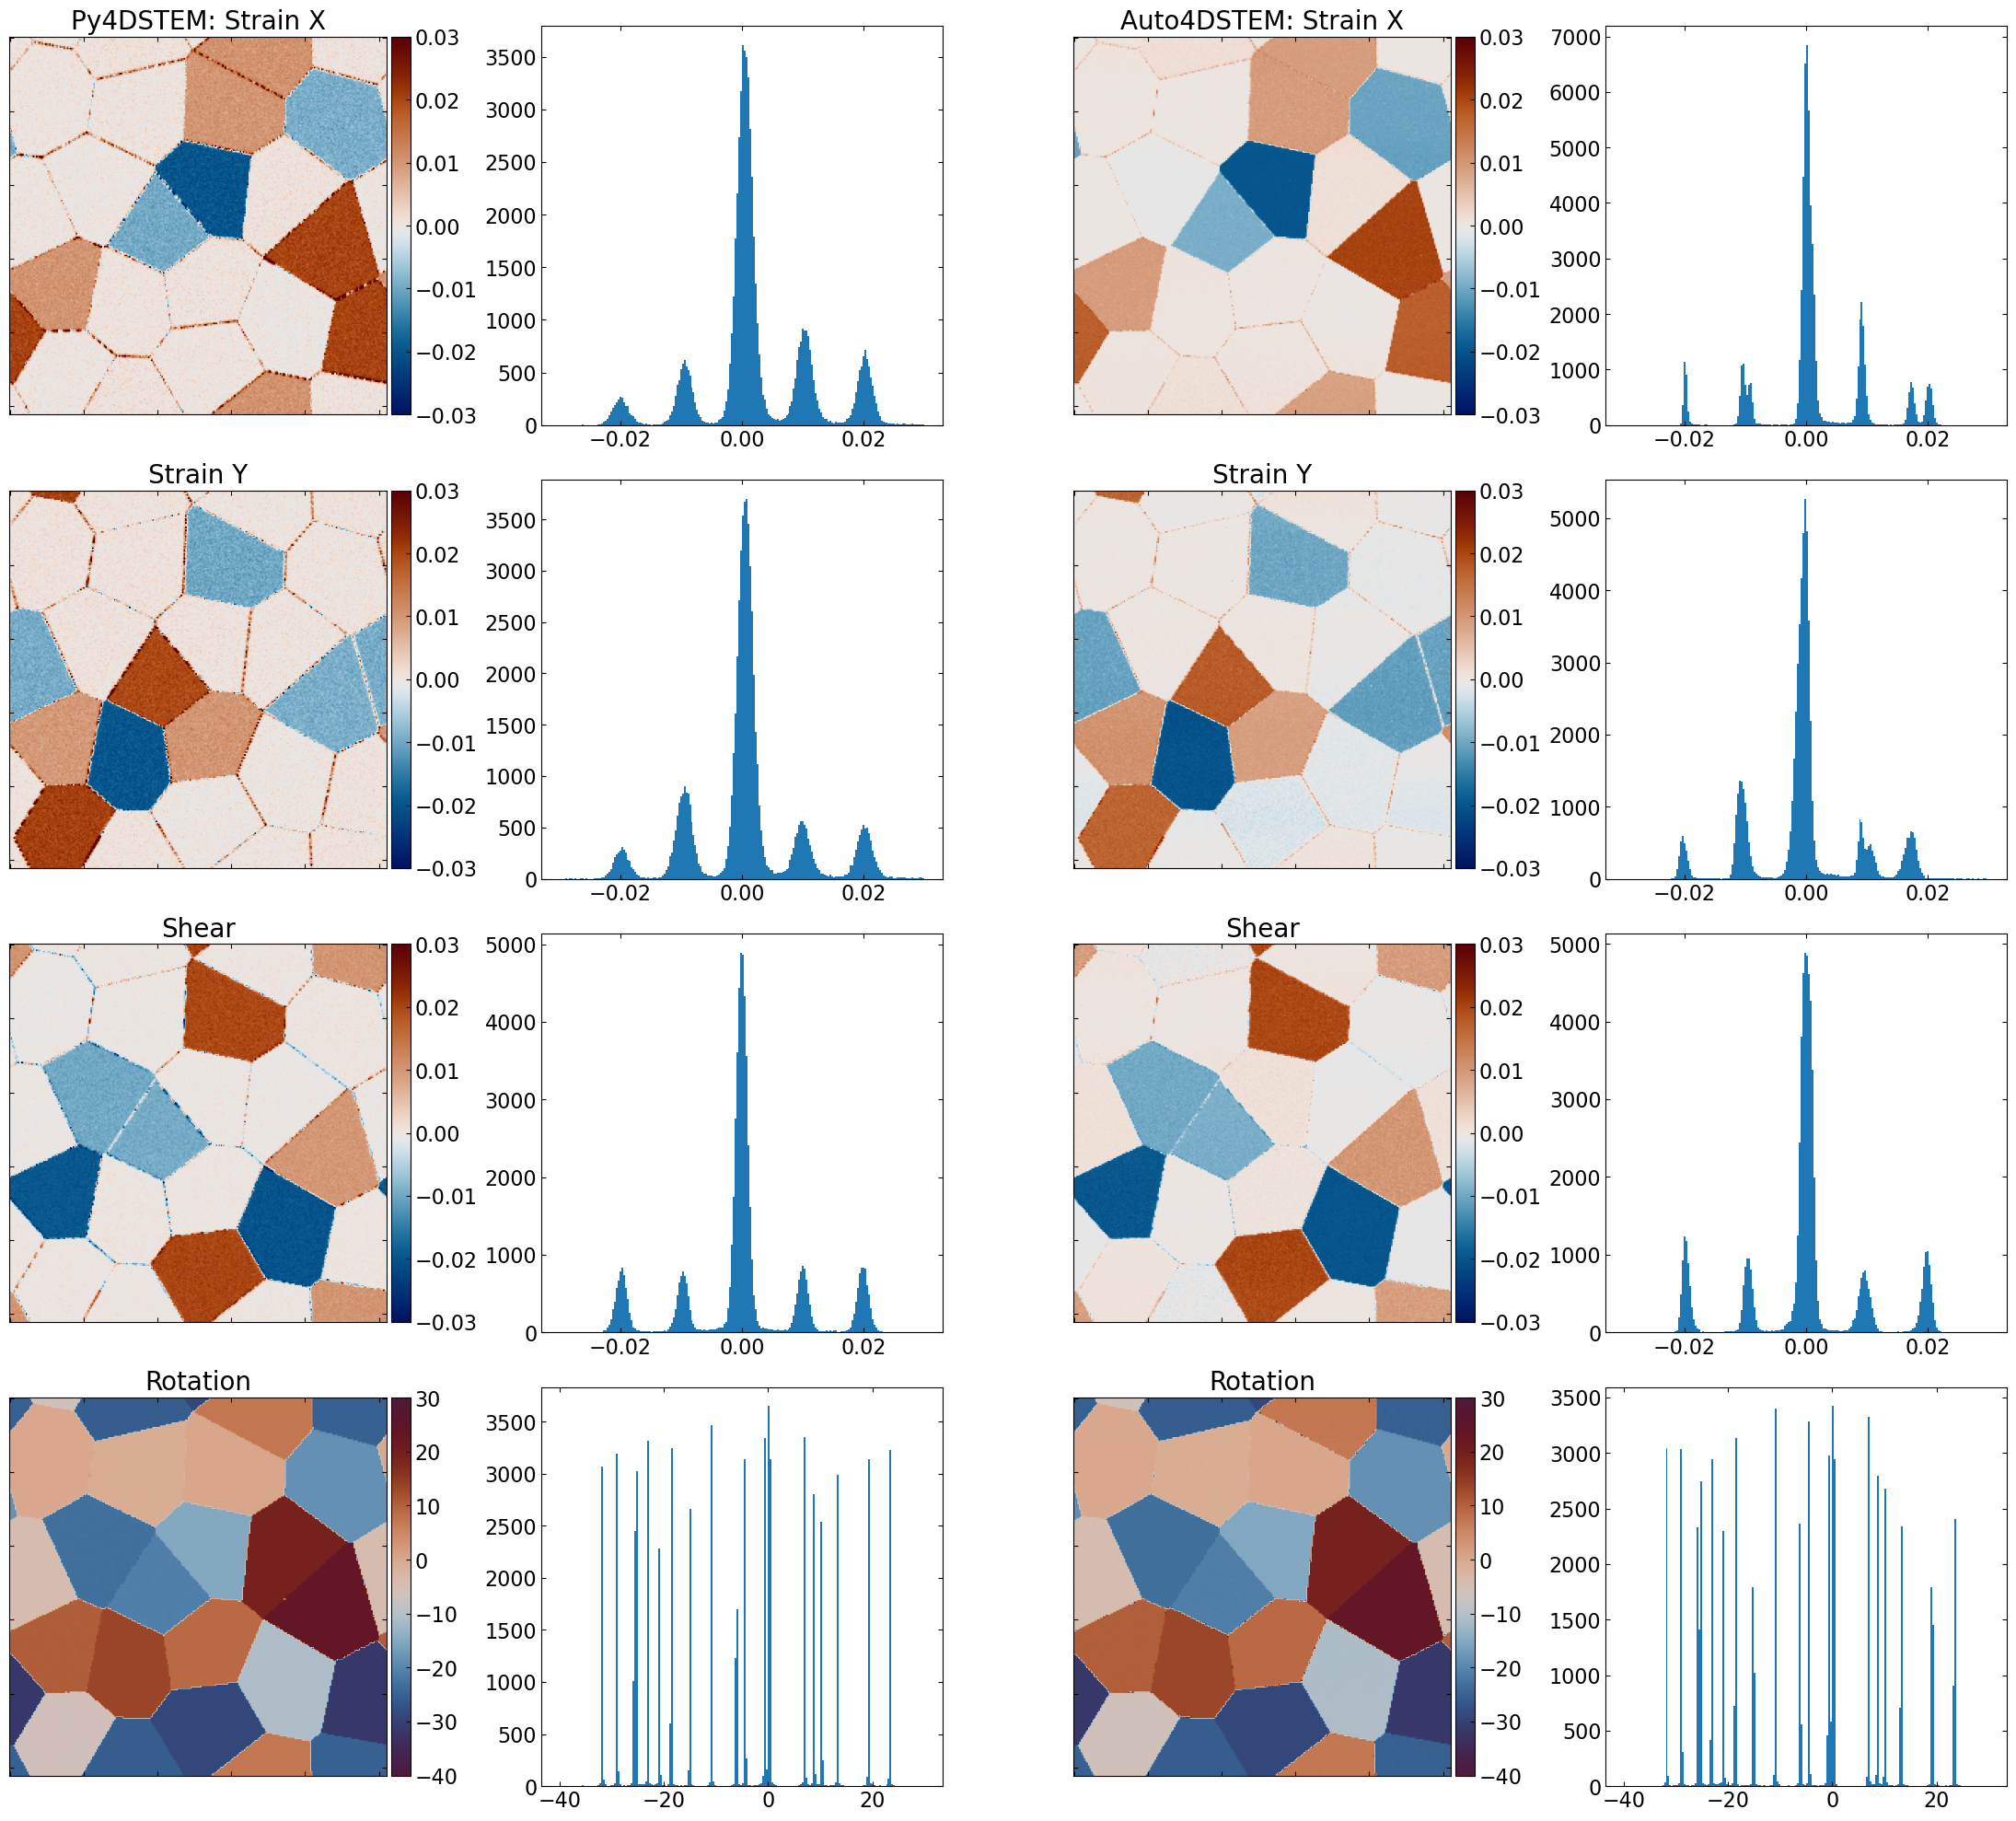

In [111]:
visual.visual_strain()

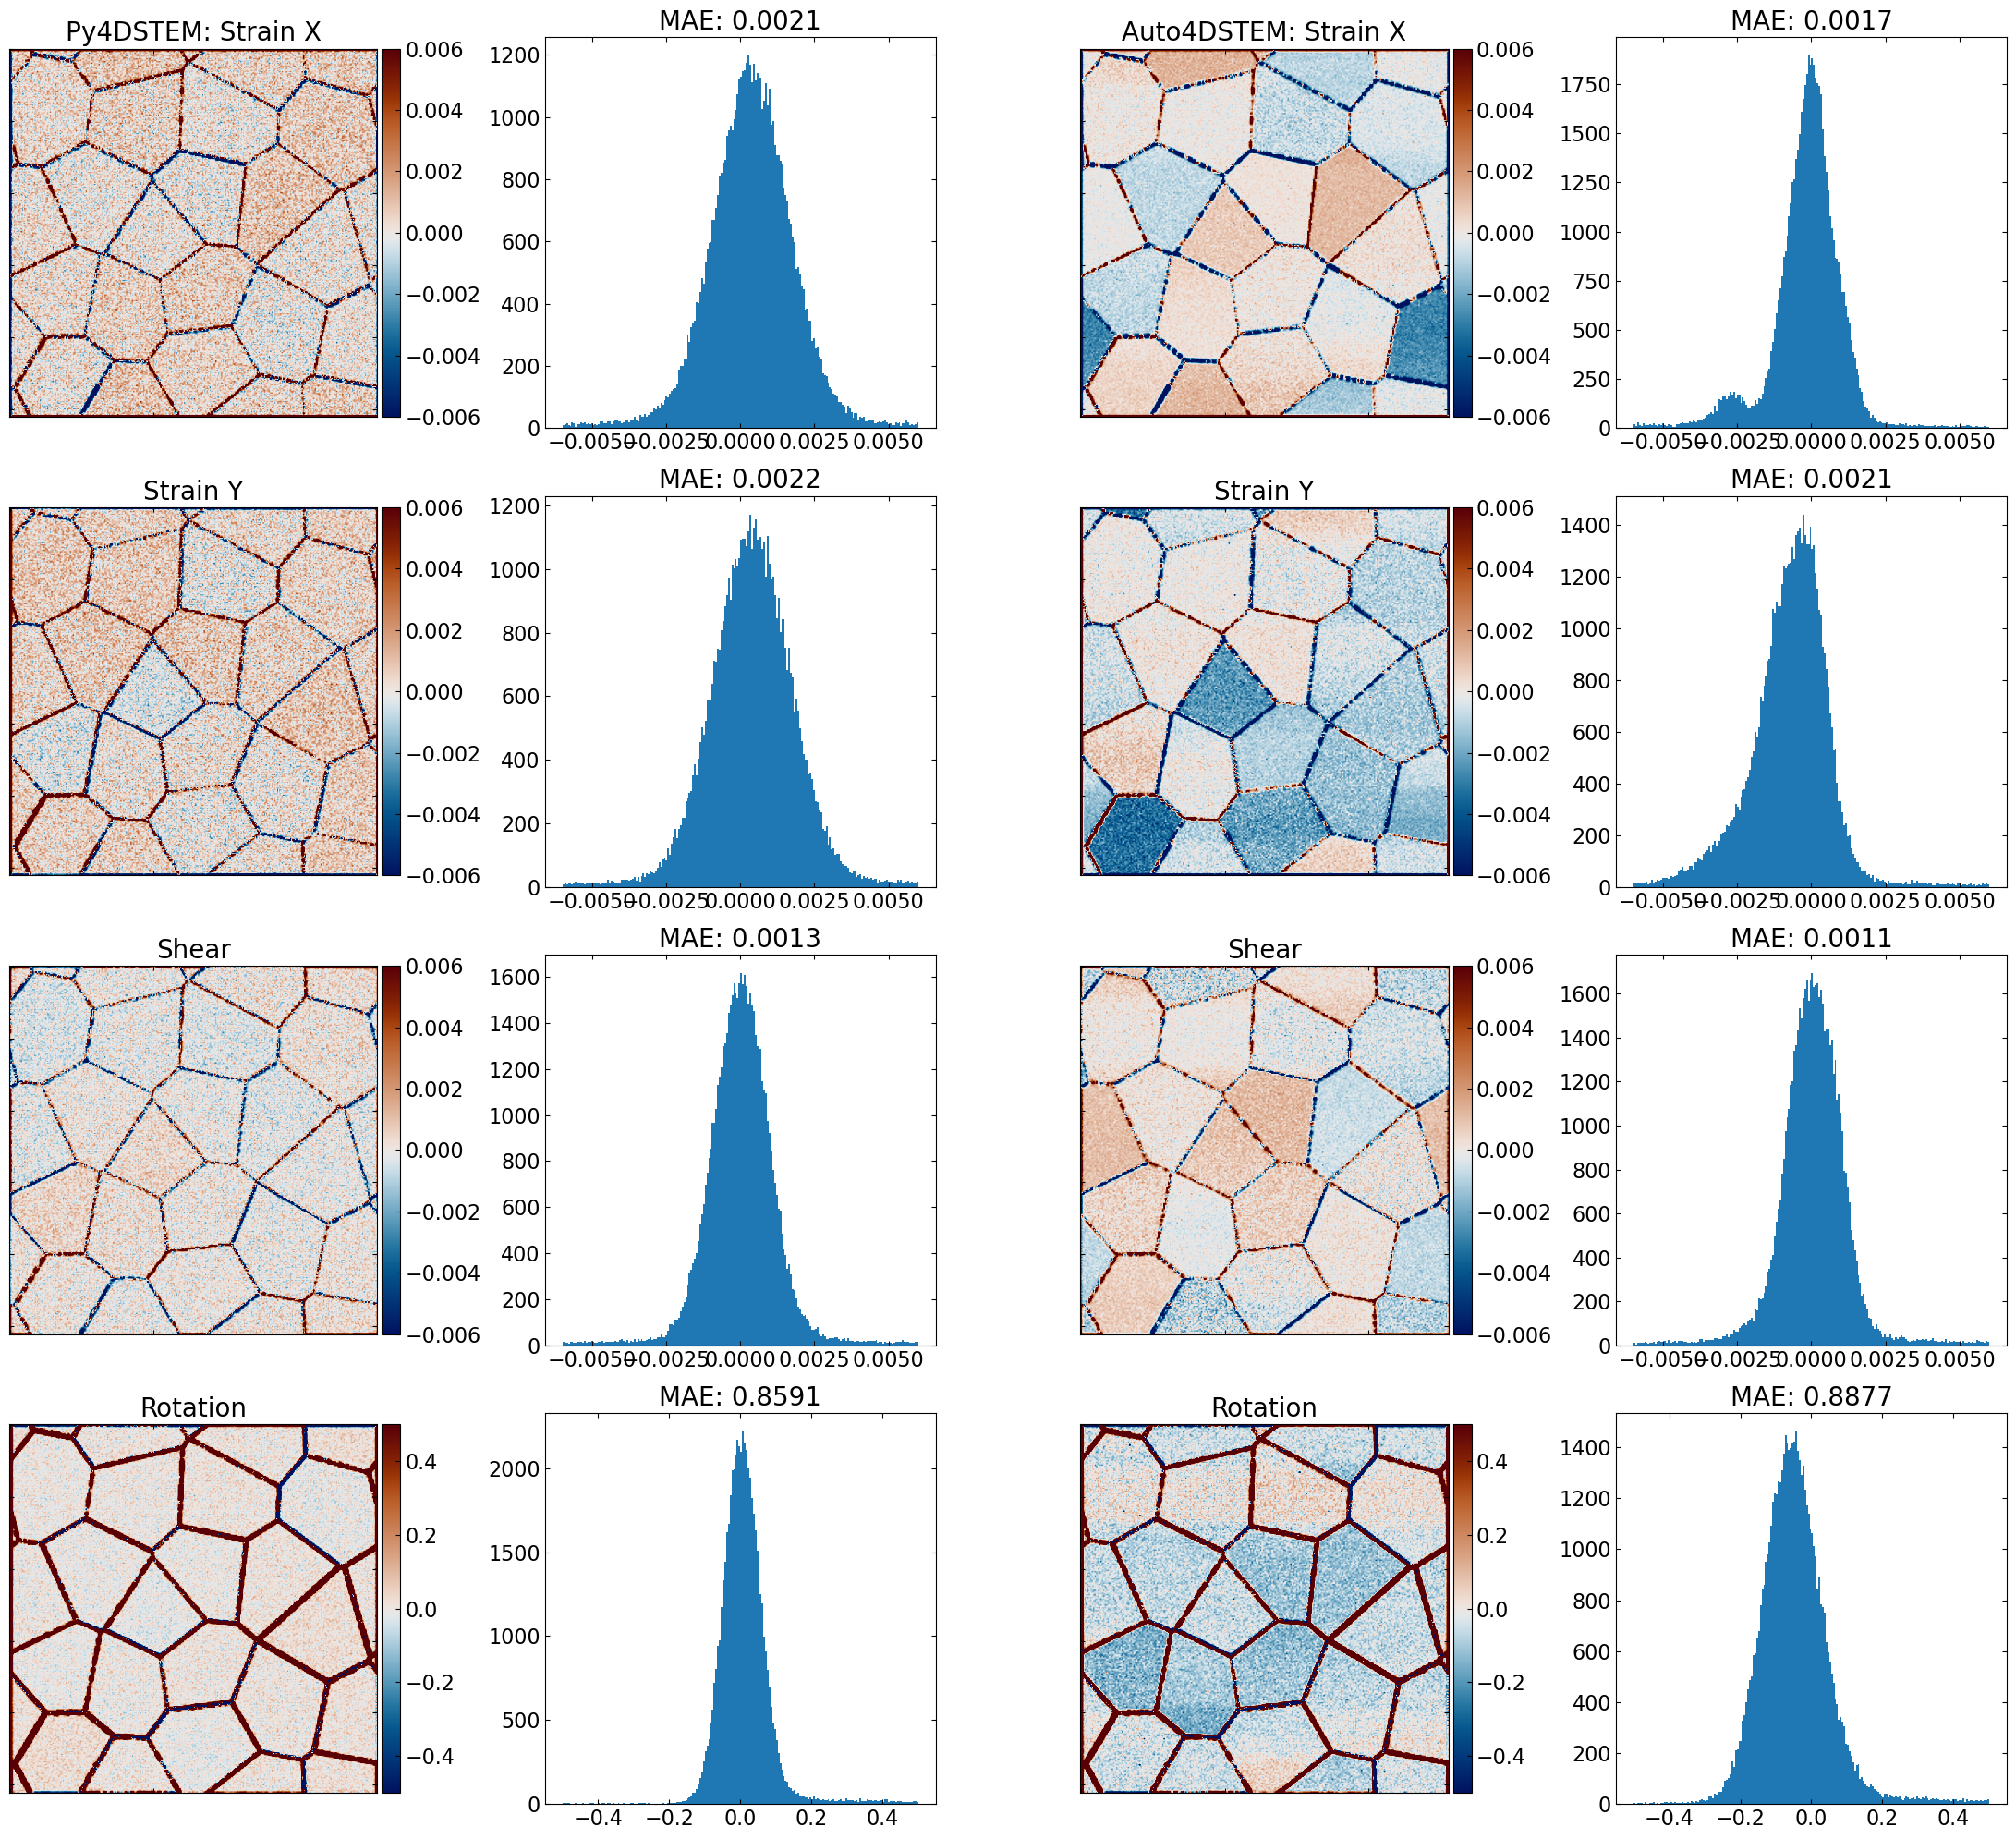

In [112]:
visual.visual_diff()

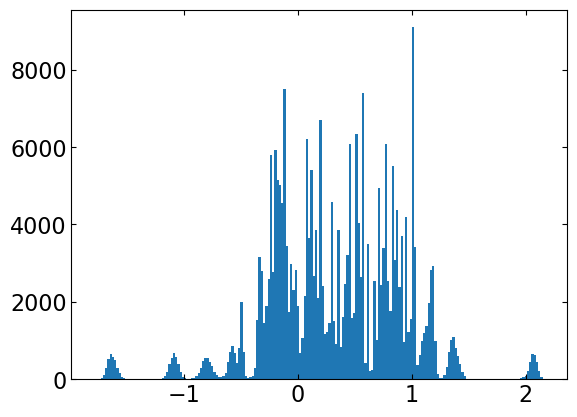

In [113]:
plt.hist(encoder_out.reshape(-1),200);

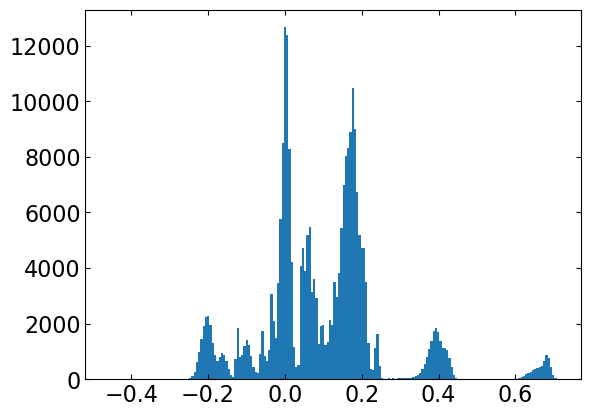

In [115]:
plt.hist(decoder_out.reshape(-1),200);

In [116]:
np.save('encoder_out_pytorch_1008.npy',encoder_out)

In [117]:
np.save('decoder_out_pytorch_1008.npy',decoder_out)